# STUAART: Continuous Multi-Day Mass Visualization

This Google Colab notebook is designed to process and visualize raw mass data collected by the STUAART system. Additionally, the average mass per time bin can be computed.

Key Features:
- Multi-Day Continuity: Merges data from multiple daily CSV files into a single, linearized timeline.  
- Absolute Clock Alignment: Automatically calculates offsets based on the experiment's start time to view data in cumulative clock time format.  
- Ground Truth Validation: Overlays manual scale measurements directly onto the automated data for accuracy checks.  
- Signal Processing: Includes built-in convolution filters to smooth raw data and highlight underlying trends.  
- Flexible Windows: Supports precise "zooming" into specific hours or days using either relative time or clock-time strings.  

Instructions:
1. Ensure your raw STUAART CSV files are uploaded to your Google Drive.  
2. Update the file paths and experimental parameters in Step 2.  
3. Run all cells to generate individual scale plots and a combined smoothed mass trend.  

Note that you must run your raw data in *Remove buffer flush indicators in raw data.ipynb* before running this Colab.

# 1. Setup and Libraries

This cell imports the necessary Python libraries for data manipulation (pandas, numpy), visualization (matplotlib), and file system management.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.ndimage import uniform_filter1d
import gc
from scipy.stats import binned_statistic

# Step 2 : User configuration and Drive mounting

**The user must define these variables :**
1. Paths:
 - Change `project_directory` and `data_path `to point to your data in your Google Drive.

2. Visualisation:
 - `color_scales` : Defines the color of each scale.
 - `save_figure` : If True, figures are saved in a new folder *Figures*.
 - `time_window` : Defines range of display. Use *None* to display the full duration, a tuple of numbers for **relative time** (e.g. (0,5)), or a tuple of strings for **absolute clock time** (e.g. ("8:00","12:00")).
 - `figure_format` : A string that defines in which format you want your figures to be saved ("eps", "png", etc.)
 - `display_relative_mass_change` : If True, the mass time series are displayed as the relative mass change, where the mass at the beginning of the `time_window` is set to 0 %.
 - `save_data` : Bool. If True, the mass in the selected `time_window`, the average mass over time, and the average mass per `time_bin` are saved in three CSV files.
 - `time_bin` : Float, in hours. Defines the time range to average the mass.

3. Days selection:
  - `days` : A list of days to visualise (e.g. [1,2] or ["2026.04.01"]). Note that this variable must be a list even if only one day is selected.

4. Ground truth mass (optional):
  - `manual_mass` : Add your manual scale measurements here as a list of tuples in the format (day, time, mass). The day can be either integers (e.g. 1) or strings (e.g. "2026.04.01"). The time can either be integers/floats (for relative time) or strings (for absolute clock time in the format "HH:MM")

`debug_mode` : If True, prints more informations for the user.

After configuring these variables, the next cell will prompt you to mount your Google Drive to grant access to the files.

In [ ]:
# Change these variables
project_directory = "/content/drive/My Drive/DCCM_Lab/labdata/vpineaunoel/stuaart"
data_path = project_directory + "/20260310-3MiceInSTUAARTs_1/orange-172.16.6.6/WithoutBufferFlushes-BaselineCorrectedAndOutlierRemoval-DBSCANwithManualCorrections/"
color_scales = ["b", "r", "g"]
save_figure = False
save_data = True
debug_mode = False
display_relative_mass_change = False
time_acquired_with_millis = False
time_window = None # is either (number, number) for relative time, (str, str) for absolute clock time or None to display all data of the day
days = [1,2,3] # is either the day number (starting from 1) or the date in the format "YYYY.MM.DD". Must be a list.
sampling_rate = 80
figure_format = "png"
time_when_day_starts_end_ends = [7, 19]
time_bin = 2.0

# Add in the list the real mass measurements done during the experiment.
# Format : (day, time, mass)
manual_mass = None
# manual_mass = [
#     (1, "11:13", 28.8),
#     (2, "11:51", 28.3),
#     (3, "15:41", 27.8),
#     (4, "10:10", 28.5),
#     ]

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
os.chdir(project_directory)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# 3. File Indexing and Date Extraction

This cell scans the provided data directory and sorts the CSV files. It automatically extracts the acquisition dates and assigns a relative day number (1, 2, 3...) to each file based on the filename prefix (e.g., YYYY.MM.DD-metadata.csv). This indexing allows the script to correctly map your selection in the days variable to the physical files on the drive.

In [ ]:
files = os.listdir(data_path)
files.sort()

dates_of_experiment = []
relative_days_of_experiment = []
i = 1
for file in files: # put in order the dates of the experiments based on the beginning of the CSV file names.
  if file.endswith(".csv"):
    index_first_dash = file.find("-")
    dates_of_experiment.append(file[:index_first_dash])
    relative_days_of_experiment.append(i)
    i += 1

if debug_mode:
  print("Dates of experiment : ", dates_of_experiment)
  print("Relative days of experiment : ", relative_days_of_experiment)

# 4. Time Mode Identification

This cell identifies the time mode according to the format of *time_window*.

- If *time_window* are strings (such as ("8:00","12:00")), *clock_time* is True.
- If *time_window* are integers/floats (such as (1.5, 2)), *clock_time* is False.
- If *time_window* is None, *clock_time* is None.

In [ ]:
if time_window is None: # no time window selected
  clock_time = False
elif all(isinstance(i, (int, float)) for i in time_window): # relative time
  clock_time = False
elif all(isinstance(i, (str)) for i in time_window): # absolute clock time
  clock_time = True

if debug_mode:
  print("Time window : ", time_window)
  print("Clock time : ", clock_time)

# 5. Linearizing the Time Window and Format Days

To allow for seamless visualization across multiple days, this cell "linearizes" your time selection. If you are using absolute clock time (e.g., from 15:00 on Day 1 to 10:00 on Day 2), the script converts these strings into a continuous float value. It achieves this by (1) converting "HH:MM" strings into decimal hours and (2) adding an offset of 24 hours for every day elapsed since the start of the experiment. For example, "02:00" on Day 2 becomes 26.0 hours ($2 + 24$). This creates a single, continuous timeline, making it possible to zoom into specific periods that span across midnight without breaking the data processing logic.

Additionally, the definition of days depends on the context and is fixed here. If both days and time_window are None, the entire time series across all days is considered. If days is None but time_window is provided, only the first day is considered.

Finally, the script calculates a start_shift based on the first file of the entire experiment (files[0]). This calculation ensures that the clock time remains consistent across all loaded files, allowing the script to correctly map all timestamps to the actual time of day.   

In [ ]:
def str_to_float_hour(time_str):
    """Convert str hour in the format 00:00 to a float value"""
    hours, minutes = map(int, time_str.split(':'))
    return hours + (minutes / 60.0)


def format_time_window_and_days(time_window, days, dates_of_experiment, relative_days_of_experiment, start_shift):
  if days is None and time_window is not None: # if no day is specified, but a time window is, the first day is considered
    days = [1]

  elif days is None and time_window is None: # if days and time_window are None, considers all data
    days = relative_days_of_experiment
    time_window = (0, 24)

  elif days is not None and time_window is None: # if time_window is None, all days defined in days are considered
    time_window = (0, 24)

  # Access first and last day of days
  start_day = days[0]
  end_day = days[-1]
  if all(isinstance(day, (int, float)) for day in days):
    formatted_start_day = days[0]
    formatted_end_day = days[-1]
  elif all(isinstance(day, str) for day in days):
    formatted_start_day = dates_of_experiment.index(days[0]) + 1
    formatted_end_day = dates_of_experiment.index(days[-1]) + 1
  else:
    raise ErrorValue("Days is not ints or strings. Verify the definition of days in cell 2.")

  if all(isinstance(time, (int, float)) for time in time_window):
    start_time_in_float = time_window[0] + start_shift
    end_time_in_float = time_window[1] + start_shift
  elif all(isinstance(time, str) for time in time_window):
    start_time_in_float = str_to_float_hour(time_window[0])
    end_time_in_float = str_to_float_hour(time_window[1])

  new_start_time = start_time_in_float + ((formatted_start_day-1) * 24)
  new_end_time = end_time_in_float + ((formatted_end_day-1) * 24)

  if debug_mode:
    print("Start time : ", start_time_in_float)
    print("End time : ", end_time_in_float)
    print("Formatted start day : ", formatted_start_day)
    print("Formatted end day : ", formatted_end_day)
    print("Time window after formatting : ", (new_start_time, new_end_time))
    print("Selected days : ", days)

  return days, (new_start_time, new_end_time)


def format_day_times(time_when_night_start_and_end, days, time_window):
  formatted_day_times = []
  for day in days:
    formatted_day_times.append((time_when_night_start_and_end[0] + ((day-1) * 24), time_when_night_start_and_end[1] + ((day-1) * 24)))
  return formatted_day_times

# compute start shift according to the time the experiment started on the first day
if time_acquired_with_millis:
  absolute_first_file = data_path + files[0]
  first_data = pd.read_csv(absolute_first_file)
  first_duration = first_data.iloc[-1, 0] / (1000 * 60 * 60)
  start_shift = (24.0 - first_duration) % 24
else:
  start_shift = 0

if debug_mode:
  print("Start shift : ", start_shift)

days, time_window = format_time_window_and_days(time_window=time_window, days=days, dates_of_experiment=dates_of_experiment, relative_days_of_experiment=relative_days_of_experiment, start_shift=start_shift)
day_times_per_day = format_day_times(time_when_night_start_and_end=time_when_day_starts_end_ends, days=days, time_window=time_window)

# 6. Data Loading and Global Alignment

This cell performs the core data aggregation and temporal alignment required for multi-day analysis.

1. Global Clock Alignment: The previously computed start_shift is used to align the time to the absolute clock time.   
2. Data Accumulation Loop: It iterates through your selected days, identifying the correct file paths whether you provided day numbers or specific dates. It then extracts the raw millisecond data, converts it into decimal hours, and applies the global shift to the dataset of each day.  
3. Merging and Filtering: All selected data points are merged into two primary arrays: *time_hour* and *mass_data*. Finally, the script uses a boolean mask to filter these arrays, retaining only the measurements that fall precisely within your defined *time_window*. This process enables the seamless visualization of a continuous timeline, even when the data spans across multiple files.

In [ ]:
all_time_hour = []
all_mass_data = []

if len(days) > 1:
  all_days = range(days[0], days[-1]+1, 1)
else:
  all_days = days

for d in all_days:
  if type(d) == str:
      actual_day_index = dates_of_experiment.index(d) # ex: 0, 1, 2...
      current_data_path = data_path + files[actual_day_index]
  else:
      actual_day_index = d - 1
      current_data_path = data_path + files[actual_day_index]

  if debug_mode:
    print("Data path : ", current_data_path)
  data = np.array(pd.read_csv(current_data_path))
  time = data[:,0]

  if time_acquired_with_millis:
    current_time_hour = time/(1000 * 60 * 60)
    current_time_hour = (start_shift + current_time_hour)
  else:
    current_time_hour = time

  current_mass_data = data[:, 1:]

  all_time_hour.append(current_time_hour)
  all_mass_data.append(current_mass_data)

print("All time hour : ", all_time_hour, len(all_time_hour), all_time_hour[0].shape)
# all data is contained in time_hour and mass_data after these two lines
time_hour = np.concatenate(all_time_hour)
mass_data = np.concatenate(all_mass_data, axis=0)

if time_acquired_with_millis is False:
  diffs = np.diff(time_hour)
  rollover_next_day = diffs < -12.0
  rollovers = np.concatenate(([False], rollover_next_day))
  days_passed = np.cumsum(rollovers)
  print("rollovers : ", rollovers, rollovers.shape, np.unique(rollovers))
  if 1.0 in all_days and np.any(rollovers):
    time_hour = time_hour + (days_passed * 24.0)
  elif not np.any(rollovers):
    time_hour = time_hour + ((d-1) * 24.0)
  else:
    indices_to_remove = np.where(days_passed == 0)[0]
    mass_data = np.delete(mass_data, indices_to_remove, axis=0)
    time_hour = np.delete(time_hour, indices_to_remove)
    time_hour = time_hour + ((d-1) * 24.0)

print(f"Beginning {time_hour[0]:.3f} and end {time_hour[-1]:.3f} value of time overall.")

mask = (time_hour >= time_window[0]) & (time_hour <= time_window[1])
time_in_window_hour = time_hour[mask]
mass_data_in_window = mass_data[mask, :]

# Initialize a mask of all True (Assume everything is night)
is_night = np.ones(len(time_in_window_hour), dtype=bool)
for day_start, day_end in day_times_per_day:
    is_day = (time_in_window_hour >= day_start) & (time_in_window_hour <= day_end)
    is_night[is_day] = False
night_indicator_list = is_night.astype(int)

if debug_mode:
    print("Time window input : ", time_window)
    if len(time_hour) > 0:
      print(f"Time window in absolute clock time : Start {time_in_window_hour[0]:.3f} and End {time_in_window_hour[-1]:.3f}")
    else:
      print("No data found in mask")

    print("Time_hour : ", time_hour, time_hour.shape)
    print(f"Time_hour_in_window : {time_in_window_hour}{time_in_window_hour.shape}")
    print("Mass_data : ", mass_data_in_window, mass_data_in_window.shape)
    print("Night indicator list : ", np.unique(night_indicator_list), night_indicator_list.shape)

All time hour :  [array([11.55369833, 11.55370028, 11.55370333, ..., 23.99999306,
       23.99999667, 24.        ]), array([5.50000000e-05, 5.66666667e-05, 5.97222222e-05, ...,
       2.39985169e+01, 2.39985206e+01, 2.39985239e+01]), array([0.00000000e+00, 2.77777778e-06, 5.83333333e-06, ...,
       9.83608056e+00, 9.83608389e+00, 9.83608750e+00])] 3 (3551548,)
rollovers :  [False False False ... False False False] (13182169,) [False  True]
Beginning 11.554 and end 57.836 value of time overall.


# 7. Processing and Filtering Manual Measurements (Ground Truth)

This cell handles the manual scale measurements (ground truth) provided by the user, ensuring they are correctly positioned on the continuous multi-day timeline.

1. Time Linearization (*format_manual_mass()*): Just as the raw data was shifted to create a continuous timeline, this function converts the *manual_mass* tuples into linearized values. It identifies the correct day of the experiment and adds a 24-hour offset for each elapsed day. This ensures that a manual weighing at 10:00 AM on Day 2 is accurately mapped to Hour 34.0 on the graph.  
2. Window Filtering (*filter_manual_measurements()*): This function sifts through the linearized manual measurements and retains only those that fall within your *time_window*.  

Output: The resulting *real_mass* variable contains the specific data points that will be overlaid on the final plot for visual validation of the STUAART accuracy to track the mass.

In [ ]:
def filter_manual_measurements(measurements, current_days, dates_of_experiment, current_window, is_clock_mode):
  filtered_times = []
  filtered_masses = []

  for m_time, m_mass in measurements:
    # convert time in float
    if isinstance(m_time, str):
      t_float = str_to_float_hour(m_time) # function defined in that last cell
    else:
      t_float = m_time # relative time is kept as is

    # check time
    if current_window is not None:
      w_start = str_to_float_hour(current_window[0]) if isinstance(current_window[0], str) else current_window[0]
      w_end = str_to_float_hour(current_window[1]) if isinstance(current_window[1], str) else current_window[1]

    if not (w_start <= t_float <= w_end):
      continue

    filtered_times.append(t_float)
    filtered_masses.append(m_mass)

  return filtered_times, filtered_masses


def format_manual_mass(manual_mass, dates_of_experiment, relative_days_of_experiment, start_shift):
  if manual_mass is None:
    return None
  else:
    new_manual_mass = []
    for m_day, m_time, m_mass in manual_mass:
      if isinstance(m_day, (int, float)):
        new_day = relative_days_of_experiment[m_day-1]
      elif isinstance(m_day, str):
        new_day = dates_of_experiment.index(m_day) + 1

      if isinstance(m_time, str):
        time_in_float = str_to_float_hour(m_time)
      else:
        time_in_float = m_time + start_shift

      new_time = time_in_float + ((new_day-1) * 24)
      new_manual_mass.append((new_time, m_mass))

  return new_manual_mass


if manual_mass is not None:
  if debug_mode:
    print("Manual mass as input : ", manual_mass)
    print("Type of manual mass : ", type(manual_mass))
    print("Current days : ", days)
    print("Current time window : ", time_window, type(time_window))

  new_manual_mass = format_manual_mass(manual_mass=manual_mass, dates_of_experiment=dates_of_experiment, relative_days_of_experiment=relative_days_of_experiment, start_shift=start_shift)
  real_mass = filter_manual_measurements(measurements=new_manual_mass, current_days=days, dates_of_experiment=dates_of_experiment, current_window=time_window, is_clock_mode=clock_time)

  if debug_mode:
    print("Real mass after formatting : ", new_manual_mass)
    print("Real mass after filtering with time_window : ", real_mass)

else:
  real_mass = None

# 8. Data Visualisation

This cell displays the mass time series from individual scales. Each scale is plotted on its own axis, allowing the inspection of data from each scales independently. If *manual_mass* is not empty, those measurements are overlayed on the mass time series with a yellow star for immediate visual comparison. The time is displayed as a cumulative time of day. If *save_figure* is True, the figure is saved in a folder named *Figures*.

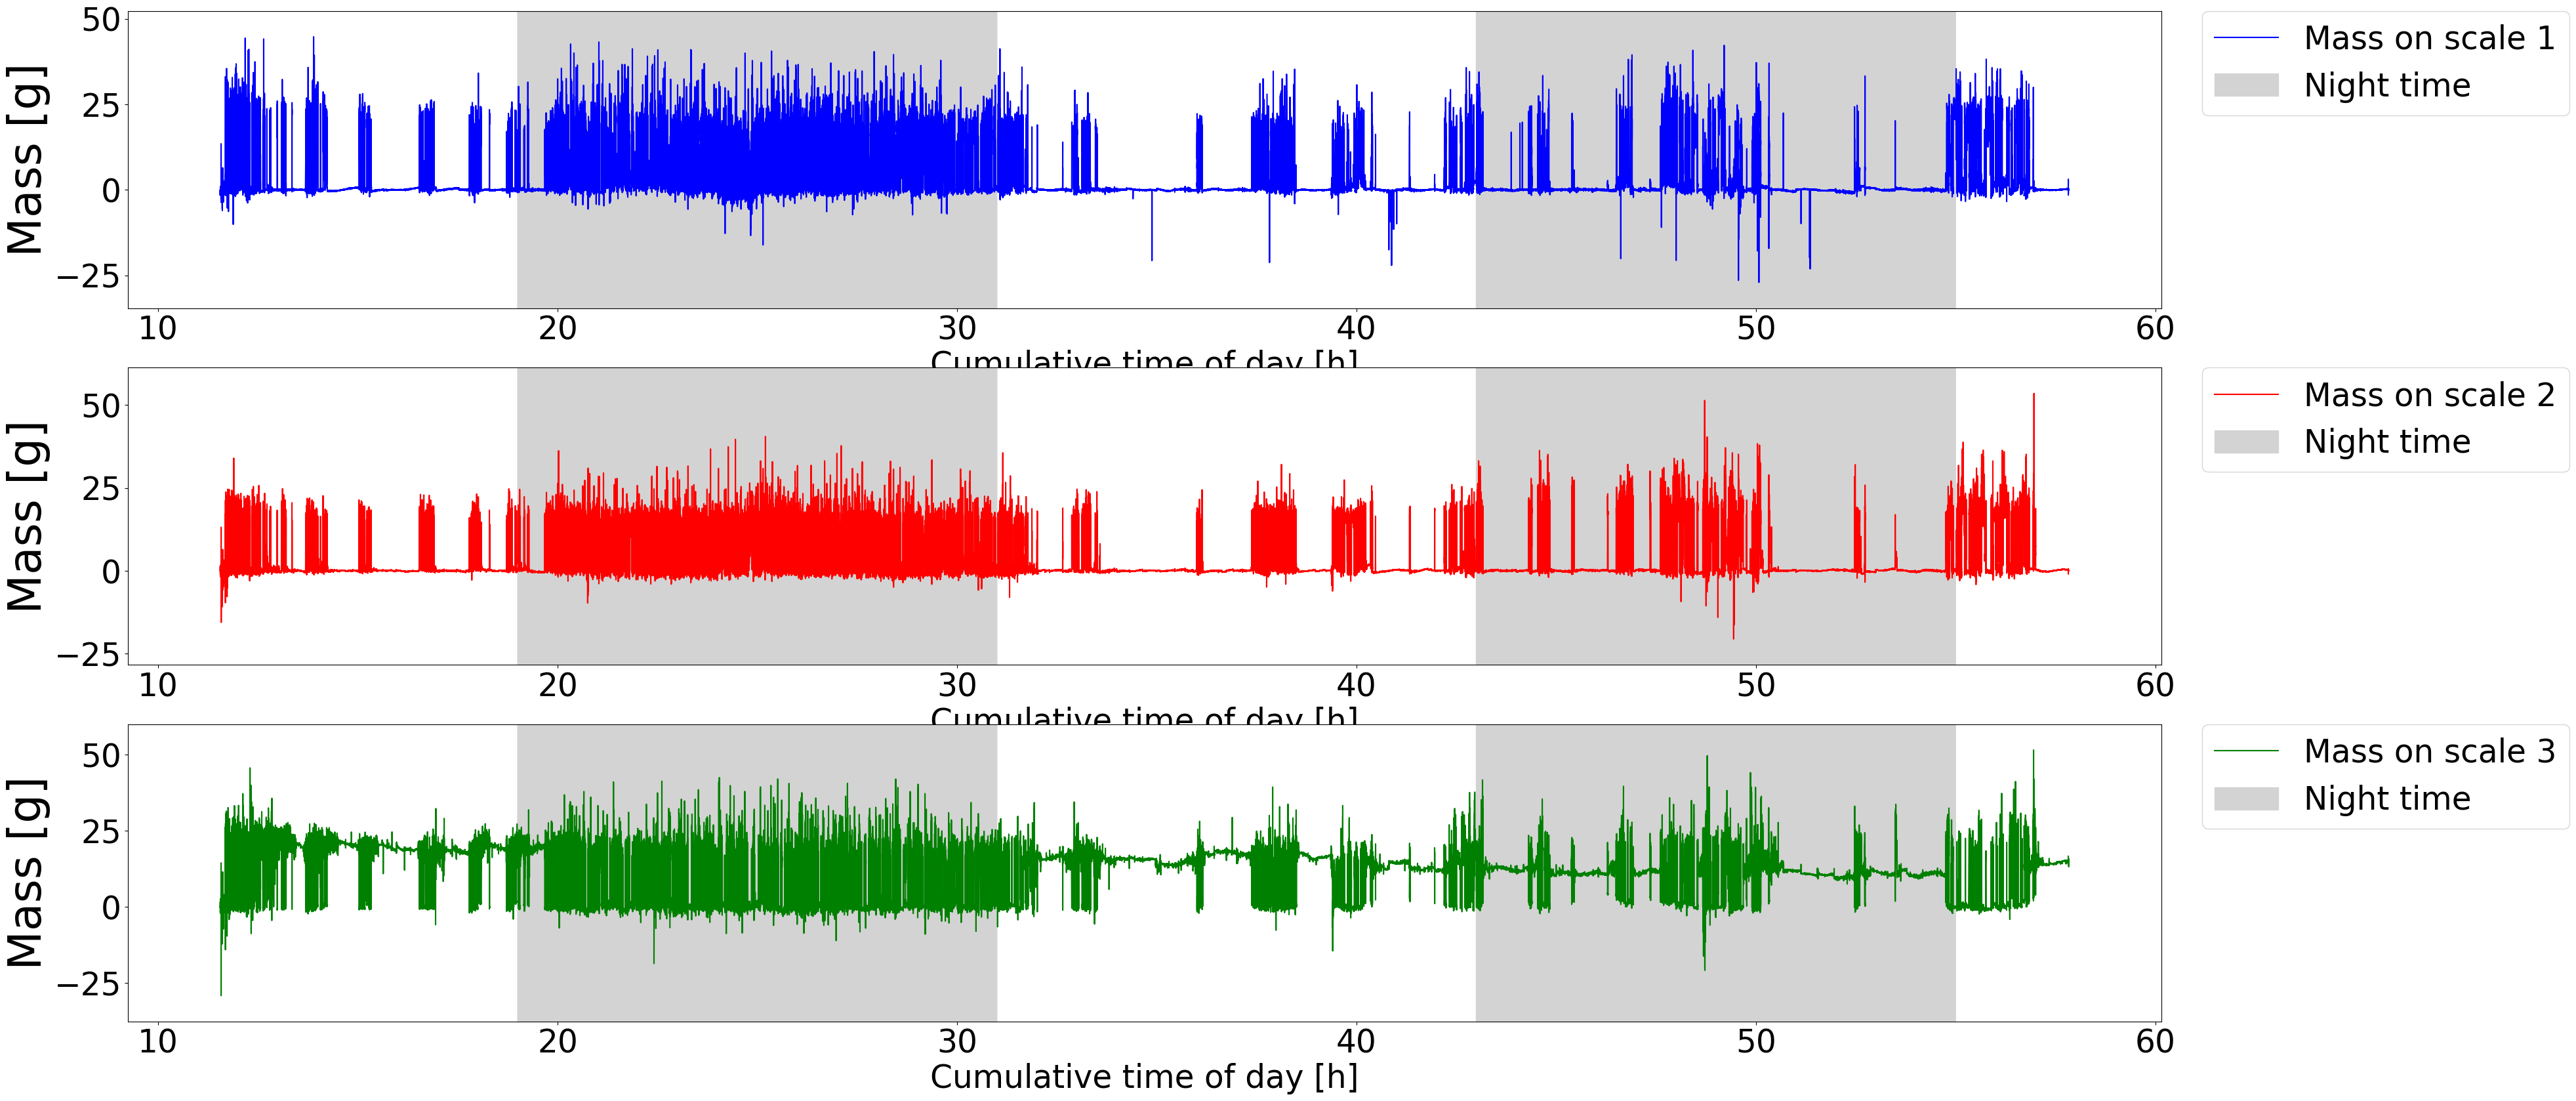

In [ ]:
def plot_raw_mass_time_series(time, data, is_saved, colors, real_mass, clock_time, time_window, figure_format, night_indicator_list):
  fig, axs = plt.subplots(data.shape[1], 1, figsize=(40,20))

  for i in range(data.shape[1]):

    if time.shape[0] > 1000000:
      # If the array is massive, plot every Nth point to prevent Colab from freezing.
      # Adjust 'step' based on how dense your raw data is.
      step = 1 if len(time) < 1000000 else len(time) // 1000000
      axs[i].plot(time[::step], data[::step,i], color=colors[i], label = "Mass on scale " + str(i+1), zorder=2)
    else:
      axs[i].plot(time, data[:,i], color=colors[i], label = "Mass on scale " + str(i+1), zorder=2)

    if real_mass is not None:
      axs[i].scatter(real_mass[0], real_mass[1], marker="*", edgecolors="k", color="m", label="Real mass", s=3000, zorder=3)

    axs[i].set_xlabel("Cumulative time of day [h]", fontsize=35)
    axs[i].set_ylabel("Mass [g]", fontsize=50)
    axs[i].tick_params(axis='both', labelsize=35)
    # axs[i].set_ylim(-10, 50)

    # nights have a lightgray background
    axs[i].fill_between(time_in_window_hour, 0, 1, where=is_night, color='lightgray', alpha=1, transform=axs[i].get_xaxis_transform(), label="Night time", zorder=1)

    axs[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=35)

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = "-Raw." + figure_format
    else:
      suffix = f"-RelativeTime-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-Raw." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    plt.savefig(save_path, format=figure_format, transparent=True, facecolor='white', edgecolor='none')
  plt.show()

plot_raw_mass_time_series(
    time=time_in_window_hour,
    data=mass_data_in_window,
    is_saved=save_figure,
    colors=color_scales,
    real_mass=real_mass,
    clock_time=clock_time,
    time_window=time_window,
    figure_format=figure_format,
    night_indicator_list=night_indicator_list)

# 9. Total Mass Visualization

This final cell calculates and visualizes the total mass of the entire STUAART.

1. Mass Aggregation: The script sums the values from all scales at each timestamp to provide a single total cage mass measurement.  
2. Outlier Filtering: Data points below a specific threshold are removed to eliminate noise from empty platforms.  
3. Smoothing: This cell applies a multi-pass convolution filter (moving average) to the data.
4. Trend Visualization: The resulting plot displays the raw aggregate mass (in gray) alongside a bold black trendline. This allows you to easily observe slow mass changes over multiple days, even in the presence of raw signal fluctuations.

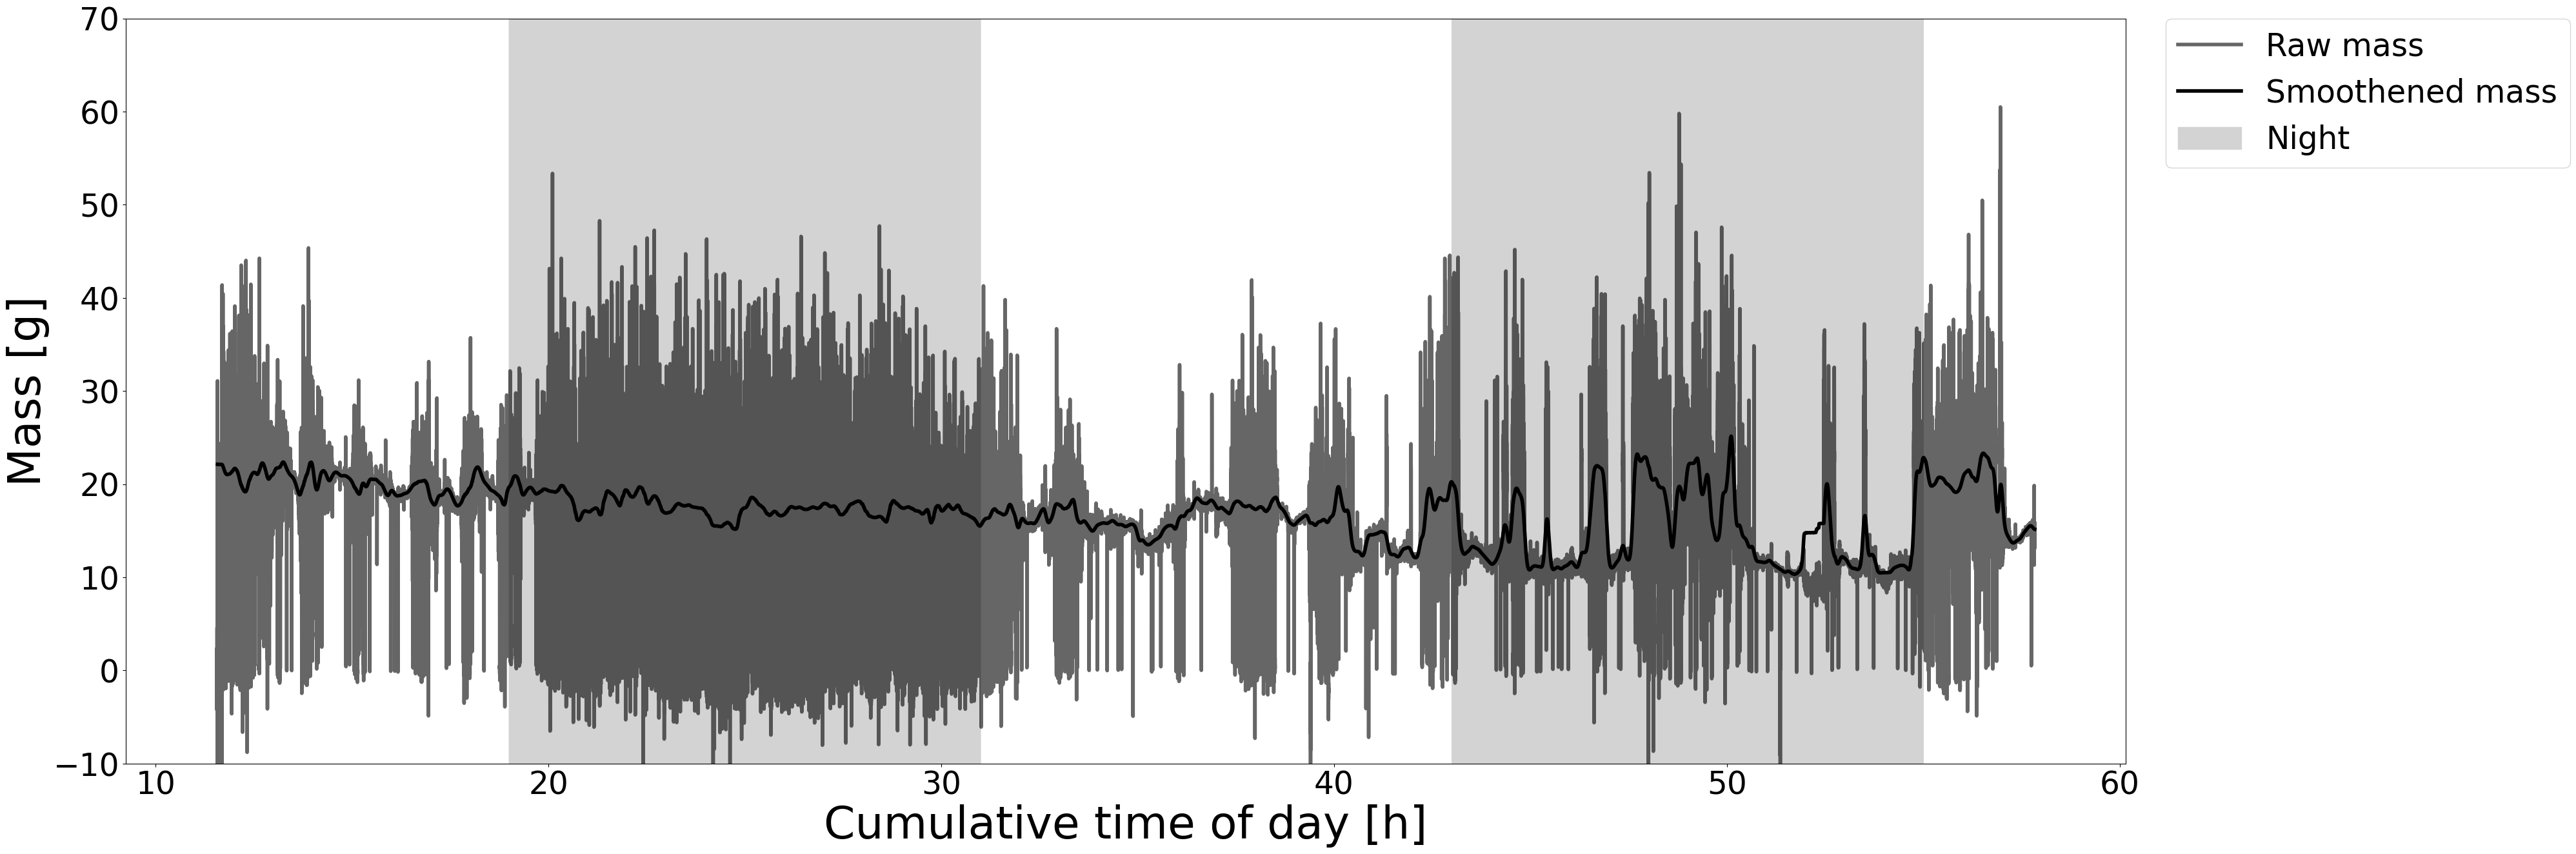

In [ ]:
def sum_data_over_time(data_per_scale):
  """
  Sum data per time point to obtain the mass measurement over time of the whole cage system (and not only per scale).
  """
  summed_data = np.nansum(data_per_scale, axis=1)
  return summed_data


def convolution_filter_with_padding_edge_average(data, length: int=10, iteration: int=1):
  """
  Optimized moving average using SciPy.
  It is significantly faster than np.convolve for large windows.
  """
  if iteration <= 0:
    raise ValueError("Number of iteration cannot be under 1")

  smoothed_data = data

  for i in range(iteration):
    # mode='nearest' extends the edge values, which prevents artificial
    # spikes at the edges of mass recordings compared to padding with global zeros/means.
    smoothed_data = uniform_filter1d(smoothed_data, size=length, mode='nearest')

  return smoothed_data


def remove_values_under_threshold(time, data, threshold: float=5):
  """
  Remove every data points under a specified threshold

  Arguments:
  - threshold: specified threshold. default is 5.
  """
  mask = data >= threshold
  return time[mask], data[mask]


def compute_mean_data(time, summed_data, smooth_level: int=3):
  """
  Computes the mean of the mass to smoothen it maximally and only see the tendency of the mass change over time.
  First removes all data points under 10 g.
  Then convolves the data using 600 points.

  smooth_level : The higher, the smoother. Actively, it changes the number of iterations of convolution.
  """
  clean_time, clean_data = remove_values_under_threshold(time=time, data=summed_data, threshold=10)
  convolved_data = convolution_filter_with_padding_edge_average(data=clean_data, length=10000, iteration=smooth_level)
  return clean_time, convolved_data


def display_overall_mass(time, data, is_saved, colors, real_mass, debug_mode, clock_time, time_window, figure_format, night_indicator_list, file_name, relative_days_of_experiment):
  """
  The summed mass over every timestamp is displayed as well as the smoothened data over time, done with a moving average.
  """
  convolved_time, convolved_data = compute_mean_data(time=time_in_window_hour, summed_data=summed_data_in_window, smooth_level=20)

  if debug_mode:
    print("Time before moving average : ", time, time.shape)
    print("Time after moving average : ", convolved_time, convolved_time.shape)
    print("Convolved mass data : ", convolved_data, convolved_data.shape)

  if len(relative_days_of_experiment) > 3:
    fig, axs = plt.subplots(1, 1, figsize=(60,15))
  else:
    fig, axs = plt.subplots(1, 1, figsize=(40,15))

  if time.shape[0] > 1000000:
    # If the array is massive, plot every Nth point to prevent Colab from freezing.
    # Adjust 'step' based on how dense your raw data is.
    step = 1 if len(time) < 1000000 else len(time) // 1000000
    plt.plot(time[::step], data[::step], color="black", linewidth=4, alpha=0.6, label="Raw mass", zorder=2)
  else:
    plt.plot(time, data, color="black", linewidth=4, alpha=0.6, label="Raw mass", zorder=2)

  # plt.plot(time, data, color="black", linewidth=4, label="Raw mass", zorder=2)
  plt.plot(convolved_time, convolved_data, color="black", linewidth=4, label="Smoothened mass", zorder=3)

  if real_mass is not None:
    plt.scatter(real_mass[0], real_mass[1], marker="*", edgecolors="k", color="m", label="Real mass", s=3000, zorder=4)

  plt.xlabel("Cumulative time of day [h]", fontsize=50)
  plt.ylabel("Mass [g]", fontsize=50)
  plt.tick_params(axis='both', which='major', labelsize=35)

  # nights have a lightgray background
  ax = plt.gca()
  plt.fill_between(time_in_window_hour, 0, 1, where=is_night, color='lightgray', alpha=1, transform=ax.get_xaxis_transform(), label="Night", zorder=1)

  plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=35)

  plt.ylim(-10, 70)

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = "-" + file_name + "-Raw." + figure_format
    else:
      suffix = "-" + file_name + f"-RelativeTime-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-Raw." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    plt.savefig(save_path, format=figure_format, transparent=True, facecolor='white', edgecolor='none')
  plt.show()

summed_data_in_window = sum_data_over_time(data_per_scale=mass_data_in_window)

if debug_mode:
  print("Shape of mass data before summing mass over every timestamp: ", mass_data.shape)
  print("Shape of summed data : ", summed_data_in_window.shape)
  print("Shape of time : ", time_in_window_hour.shape)

display_overall_mass(
    time=time_in_window_hour,
    data=summed_data_in_window,
    is_saved=save_figure,
    colors=color_scales,
    real_mass=real_mass,
    debug_mode=debug_mode,
    clock_time=clock_time,
    time_window=time_window,
    figure_format=figure_format,
    night_indicator_list=night_indicator_list,
    file_name="SumData",
    relative_days_of_experiment=relative_days_of_experiment)

# 10. Compute average mass per time bin and display

TODO

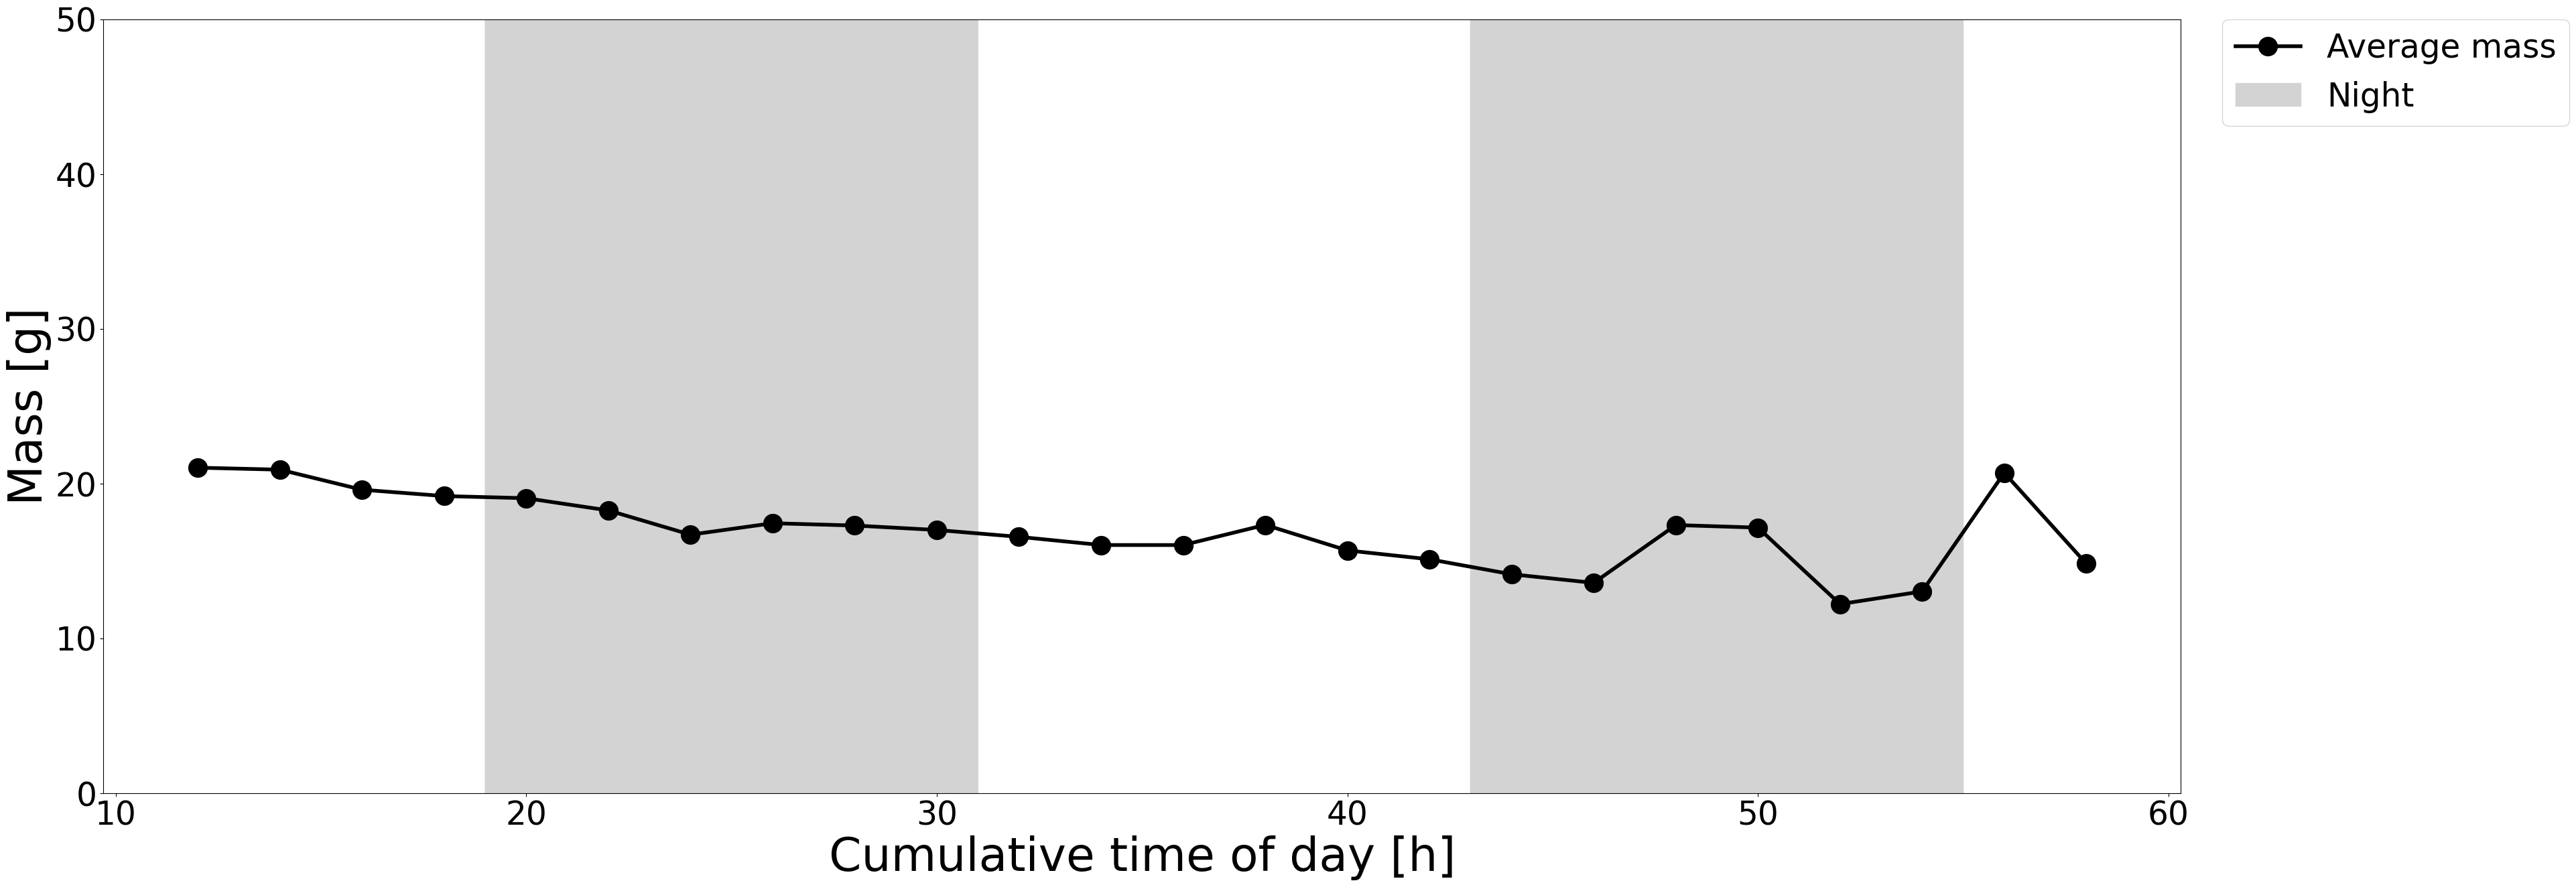

In [ ]:
def bin_mass_time_series(time_array, mass_array, bin_size=1.0):
  """
  Bins cumulative time-series mass data into regular intervals and calculates the mean mass.

  Parameters:
  - time_array (array-like): Cumulative time (e.g., in hours, starting at 10.0).
  - mass_array (array-like): Corresponding mass values for each time point.
  - bin_size (float): The width of each time bin (default: 1.0 hour).

  Returns:
  - bin_centers (np.ndarray): The mean time for each bin (e.g., 10.5, 11.5).
  - binned_mass (np.ndarray): The averaged mass for each bin.
  """
  time_array = np.asarray(time_array)
  mass_array = np.asarray(mass_array)

  # Define bin edges aligned to clean hour boundaries based on data range
  start_edge = np.floor(time_array[0])
  end_edge = np.ceil(time_array[-1])
  bin_edges = np.arange(start_edge, end_edge + bin_size, bin_size)

  # Calculate the mean mass per bin
  binned_mass, _, _ = binned_statistic(time_array, mass_array, statistic='mean', bins=bin_edges)

  # Calculate the center of each time bin (e.g., [10, 11] -> 10.5)
  bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

  # Filter out empty bins (where no data points fell into the interval, yielding NaN)
  valid_mask = ~np.isnan(binned_mass)

  return bin_centers[valid_mask], binned_mass[valid_mask]


def display_average_mass_per_time_bin(time_array, data_array, is_saved, colors, real_mass, debug_mode, clock_time, time_window, figure_format, night_indicator_list, file_name, relative_days_of_experiment):
  """
  TODO
  """
  if len(relative_days_of_experiment) > 3:
    fig, axs = plt.subplots(1, 1, figsize=(60,15))
  else:
    fig, axs = plt.subplots(1, 1, figsize=(40,15))
  plt.plot(time_array, data_array, color="black", linewidth=4, marker="o", markersize=20, label="Average mass", zorder=2)

  if real_mass is not None:
    plt.scatter(real_mass[0], real_mass[1], marker="*", edgecolors="k", color="m", label="Real mass", s=3000, zorder=3)

  plt.xlabel("Cumulative time of day [h]", fontsize=50)
  plt.ylabel("Mass [g]", fontsize=50)
  plt.tick_params(axis='both', which='major', labelsize=35)

  # nights have a lightgray background
  ax = plt.gca()
  plt.fill_between(time_in_window_hour, 0, 1, where=is_night, color='lightgray', alpha=1, transform=ax.get_xaxis_transform(), label="Night", zorder=1)

  plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=35)
  ax.set_ylim(0, 50)

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = "-" + file_name + "-Raw." + figure_format
    else:
      suffix = "-" + file_name + f"-RelativeTime-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    plt.savefig(save_path, format=figure_format, transparent=True, facecolor='white', edgecolor='none')
  plt.show()

convolved_time, convolved_data = compute_mean_data(time=time_in_window_hour, summed_data=summed_data_in_window, smooth_level=20)
time_bin_in_hour_in_time_window, average_mass_per_time_bin = bin_mass_time_series(time_array=convolved_time, mass_array=convolved_data, bin_size=time_bin)

display_average_mass_per_time_bin(
    time_array=time_bin_in_hour_in_time_window,
    data_array=average_mass_per_time_bin,
    is_saved=save_figure,
    colors=color_scales,
    real_mass=real_mass,
    debug_mode=debug_mode,
    clock_time=clock_time,
    time_window=time_window,
    figure_format=figure_format,
    night_indicator_list=night_indicator_list,
    file_name=f"AverageSumPerTimeBin-{time_bin}",
    relative_days_of_experiment=relative_days_of_experiment)

if debug_mode:
  print("Time bin in hour in time window : ", time_bin_in_hour_in_time_window, time_bin_in_hour_in_time_window.shape)
  print("Average mass per time bin : ", average_mass_per_time_bin, average_mass_per_time_bin.shape)

## 11. Produce relative mass data change over time (optional)

This cell only runs if `display_relative_mass_change` is True. It converts the absolute mass measurements (in grams) into a relative percentage change compared to the initial mass at the start of the time window ($t=0$).

The relative mass at any given time point $t$ is calculated as:

$$\Delta M_{\text{relative}}(t) = \left( \frac{M(t)}{M(0)} \right) \times 100 - 100$$

Where:
* $M(t)$ is the mass at the current time point.
* $M(0)$ is the baseline mass at the very first index of the array.
* The result is expressed as a percentage ($\%$), where $0\%$ indicates no change from the starting mass.


`compute_relative_mass_change`: A robust function that accepts both 1D arrays (single data streams) and 2D arrays (multiple scales). It automatically isolates the first row as the $t=0$ baseline and applies the normalization element-wise.
2.  **Data Transformation**: The relative mass shift is computed for three distinct datasets:
    * The raw data for each individual scale (`mass_data_in_window`).
    * The raw summed data for the entire system (`summed_data_in_window`).
    * The smoothened, convolved overall data (`convolved_data`).
3.  **Visualization**:
    * Generates a time-series plot comparing the individual scales.
    * Generates a master plot (`display_overall_mass`) overlaying the raw relative mass and the convolved relative mass to highlight the macro-trend.

In [ ]:
def compute_starting_mass(smoothened_time, smoothened_summed_mass, debug_mode=debug_mode):
  time_at_beginning = smoothened_time[0]
  thirty_minutes_later = time_at_beginning + 0.5
  index_time_at_beginning = np.where(smoothened_time == time_at_beginning)[0][0]
  index_thirty_minutes_later = np.abs(smoothened_time - thirty_minutes_later).argmin()
  mass_during_first_30_min = np.mean(smoothened_summed_mass[index_time_at_beginning:index_thirty_minutes_later])

  if debug_mode:
    print("Index time at beginning : ", index_time_at_beginning)
    print("Index thirty minutes later : ", index_thirty_minutes_later)
    print("Mass during first 30 min : ", mass_during_first_30_min)

  return mass_during_first_30_min


def compute_relative_mass_change(data, smoothened_time, smoothened_summed_data):
  if data.ndim == 1:
    data = data.reshape(-1, 1)

  relative_mass = np.zeros(shape=data.shape)
  mass_day_0 = compute_starting_mass(smoothened_time=smoothened_time, smoothened_summed_mass=smoothened_summed_data)
  for i in range(data.shape[1]):
    relative_mass[:,i] = np.divide(data[:,i], mass_day_0)*100-100

  return relative_mass


def display_relative_overall_mass(time, data, is_saved, colors, real_mass, debug_mode, clock_time, time_window, figure_format, night_indicator_list, file_name):
  """
  The summed mass over every timestamp is displayed as well as the smoothened data over time, done with a moving average.
  """
  if debug_mode:
    print("Time before moving average : ", time, time.shape)
    print("Time after moving average : ", convolved_time, convolved_time.shape)

  convolved_time, convolved_data = compute_mean_data(time=time, summed_data=data, smooth_level=20)
  relative_mass_data_in_time_window = compute_relative_mass_change(data=data, smoothened_time=convolved_time, smoothened_summed_data=convolved_data)
  convolved_relative_mass_data_in_time_window = compute_relative_mass_change(data=convolved_data, smoothened_time=convolved_time, smoothened_summed_data=convolved_data)

  fig, axs = plt.subplots(1, 1, figsize=(30,10))
  plt.plot(convolved_time, convolved_relative_mass_data_in_time_window, color="black", linewidth=4, label="Smoothened mass", zorder=3)

  if real_mass is not None:
    starting_mass = compute_starting_mass(smoothened_time=convolved_time, smoothened_summed_mass=convolved_data)
    relative_real_mass = np.divide(real_mass[1], starting_mass) * 100 - 100
    plt.scatter(real_mass[0], relative_real_mass, marker="*", edgecolors="k", color="m", label="Real mass", s=3000, zorder=4)

  plt.xlabel("Cumulative time of day [h]", fontsize=50)
  plt.ylabel("Relative mass change [%]", fontsize=50)
  plt.tick_params(axis='both', which='major', labelsize=35)

  # nights have a lightgray background
  ax = plt.gca()
  plt.fill_between(time_in_window_hour, 0, 1, where=is_night, color='lightgray', alpha=1, transform=ax.get_xaxis_transform(), label="Nights", zorder=1)

  plt.legend(loc="upper right", fontsize=35)

  # plt.ylim(-10, 70)

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = file_name + "-RelativeMassChange." + figure_format
    else:
      suffix = file_name + f"-RelativeTime-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-RelativeMassChange." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    plt.savefig(save_path, format=figure_format, transparent=True, facecolor='white', edgecolor='none')
  plt.show()


if display_relative_mass_change:
  display_relative_overall_mass(
    time=time_in_window_hour,
    data=summed_data_in_window,
    is_saved=save_figure,
    colors=color_scales,
    real_mass=real_mass,
    debug_mode=debug_mode,
    clock_time=clock_time,
    time_window=time_window,
    figure_format=figure_format,
    night_indicator_list=night_indicator_list,
    file_name="RelativeMass")

## 12. Save data

TODO

In [ ]:
if save_data:
  # Data of all scales in time window
  data_per_scale_in_time_window = {"Time [hour]":time_in_window_hour}
  for i in range(mass_data_in_window.shape[1]):
    data_per_scale_in_time_window[f"Mass scale {i+1} [g]"] = mass_data_in_window[:, i]
  df_per_scale_in_time_window = pd.DataFrame(data_per_scale_in_time_window)

  # Summed data
  convolved_time, convolved_data = compute_mean_data(time=time_in_window_hour, summed_data=summed_data_in_window, smooth_level=20)
  summed_data_in_time_window = {"Time [hour]" : convolved_time, "Summed mass [g]" : convolved_data}
  df_summed_data_in_time_window = pd.DataFrame(summed_data_in_time_window)

  # Average mass per bin
  average_mass_per_time_bin_in_time_window = {"Time [hour]" : time_bin_in_hour_in_time_window, "Average mass [g]" : average_mass_per_time_bin}
  df_average_mass_per_time_bin_in_time_window = pd.DataFrame(average_mass_per_time_bin_in_time_window)

  path = Path(data_path)
  figure_path = path / "ResultingData"
  figure_path.mkdir(parents=True, exist_ok=True)
  file_stem = path.stem
  if time_window is None:
    suffix_per_scale = "-DataPerScale.csv"
    suffix_summed_data = "-SummedData.csv"
    suffix_average_mass_per_time_bin = "-AverageMassPerTimeBin.csv"
  else:
    suffix_per_scale = f"-RelativeTime-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-DataPerScale.csv"
    suffix_summed_data = f"-RelativeTime-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-SummedData.csv"
    suffix_average_mass_per_time_bin = f"-RelativeTime-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-Timebin{time_bin}-AverageMassPerTimeBin.csv"
  save_path_per_scale = figure_path / (file_stem + suffix_per_scale)
  save_path_summed_data = figure_path / (file_stem + suffix_summed_data)
  save_path_average_mass_per_time_bin = figure_path / (file_stem + suffix_average_mass_per_time_bin)
  # df_per_scale_in_time_window.to_csv(save_path_per_scale, index=False)
  # df_summed_data_in_time_window.to_csv(save_path_summed_data, index=False)
  df_average_mass_per_time_bin_in_time_window.to_csv(save_path_average_mass_per_time_bin, index=False)

  print("Data was saved as CSV files.")

Data was saved as CSV files.
